In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset,DataLoader
from sklearn.preprocessing import OneHotEncoder,LabelEncoder,OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
import seaborn as sns

In [2]:
df = pd.read_csv('/kaggle/input/datasets/tawfikelmetwally/employee-dataset/Employee.csv')
df.head()

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1


In [3]:
df.isna().sum()

Education                    0
JoiningYear                  0
City                         0
PaymentTier                  0
Age                          0
Gender                       0
EverBenched                  0
ExperienceInCurrentDomain    0
LeaveOrNot                   0
dtype: int64

In [4]:
df['Education'].unique()

array(['Bachelors', 'Masters', 'PHD'], dtype=object)

<Axes: ylabel='Age'>

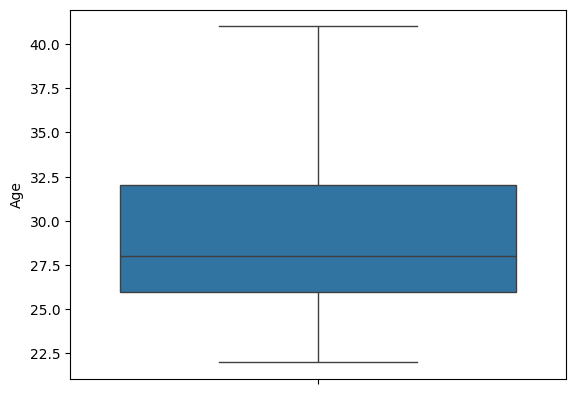

In [5]:
sns.boxplot(df['Age'])

In [6]:
df['YearsOfExperience'] = 2026 - df['JoiningYear']

In [7]:
df.head()

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot,YearsOfExperience
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0,9
1,Bachelors,2013,Pune,1,28,Female,No,3,1,13
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0,12
3,Masters,2016,Bangalore,3,27,Male,No,5,1,10
4,Masters,2017,Pune,3,24,Male,Yes,2,1,9


In [8]:
df = df.drop('JoiningYear',axis=1)

In [9]:
df.head()

,Education,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot,YearsOfExperience
0,Bachelors,Bangalore,3,34,Male,No,0,0,9
1,Bachelors,Pune,1,28,Female,No,3,1,13
2,Bachelors,New Delhi,3,38,Female,No,2,0,12
3,Masters,Bangalore,3,27,Male,No,5,1,10
4,Masters,Pune,3,24,Male,Yes,2,1,9


In [10]:
df['PaymentTier'] = df['PaymentTier'] - 1

In [11]:
df['EverBenched'] = df['EverBenched'].map({'Yes' : 1 , 'No':0})

In [12]:
X = df.drop('PaymentTier',axis=1)
y = df['PaymentTier']

In [13]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.25,random_state=42)

In [14]:
categorical_columns = X.select_dtypes(include='O').columns
numerical_columns = X.select_dtypes(exclude='O').columns

In [15]:
print(categorical_columns)
print(numerical_columns)

Index(['Education', 'City', 'Gender'], dtype='object')
Index(['Age', 'EverBenched', 'ExperienceInCurrentDomain', 'LeaveOrNot',
       'YearsOfExperience'],
      dtype='object')


In [16]:
ordinal_columns = ['Education']
cat_columns = [i for i in categorical_columns if i not in ordinal_columns]

In [17]:
print(cat_columns)

['City', 'Gender']


In [18]:
oe = OrdinalEncoder()
ohe = OneHotEncoder()

In [19]:
preprocessor = ColumnTransformer([
    ("OneHotEncoder",ohe,cat_columns),
    ("OrdinalEncoder",oe,ordinal_columns)
],remainder='passthrough')

In [20]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [21]:
X_train_df = pd.DataFrame(X_train,columns=preprocessor.get_feature_names_out())

In [22]:
X_train_df.head()

,OneHotEncoder__City_Bangalore,OneHotEncoder__City_New Delhi,OneHotEncoder__City_Pune,OneHotEncoder__Gender_Female,OneHotEncoder__Gender_Male,OrdinalEncoder__Education,remainder__Age,remainder__EverBenched,remainder__ExperienceInCurrentDomain,remainder__LeaveOrNot,remainder__YearsOfExperience
0,1.0,0.0,0.0,0.0,1.0,0.0,35.0,0.0,0.0,0.0,13.0
1,0.0,1.0,0.0,1.0,0.0,2.0,27.0,0.0,5.0,0.0,13.0
2,0.0,0.0,1.0,1.0,0.0,0.0,32.0,0.0,3.0,1.0,11.0
3,0.0,0.0,1.0,1.0,0.0,1.0,29.0,0.0,2.0,0.0,9.0
4,1.0,0.0,0.0,0.0,1.0,0.0,28.0,0.0,3.0,1.0,10.0


## DataLoader

In [23]:
class EmployeeData(Dataset):
    def __init__(self,X,y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.X)

    def __getitem__(self,idx):
        features = torch.tensor(self.X[idx],dtype=torch.float32)
        target = torch.tensor(self.y.values[idx],dtype=torch.long)
        return features,target

In [24]:
train_dataset = EmployeeData(X_train,y_train)
test_dataset = EmployeeData(X_test,y_test)

train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=32,shuffle=True)

### Model

In [25]:
class EmployeeClassifier(nn.Module):
    def __init__(self,input_dim,output_dim):
        super(EmployeeClassifier,self).__init__()

        self.network = nn.Sequential(
                nn.Linear(input_dim,128),
                nn.Dropout(p=0.2),
                nn.ReLU(),
                nn.Linear(128,64),
                nn.Dropout(p=0.2),
                nn.ReLU(),
                nn.Linear(64,32),
                nn.Dropout(p=0.2),
                nn.ReLU(),
                nn.Linear(32,output_dim),
        )

    def forward(self,x):
        return self.network(x)

In [26]:
input_dim = X_train.shape[1]
output_dim = 3

In [27]:
model = EmployeeClassifier(input_dim,output_dim)

In [28]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.01)

In [29]:
print(model)

EmployeeClassifier(
  (network): Sequential(
    (0): Linear(in_features=11, out_features=128, bias=True)
    (1): Dropout(p=0.2, inplace=False)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): Dropout(p=0.2, inplace=False)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): Dropout(p=0.2, inplace=False)
    (8): ReLU()
    (9): Linear(in_features=32, out_features=3, bias=True)
  )
)


In [30]:
epochs = 500
for epoch in range(epochs):
    model.train()
    train_correct = 0
    train_total = 0

    for (batch_X,batch_y) in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs,batch_y)

        loss.backward()
        optimizer.step()

        predicted = outputs.argmax(dim=1)

        train_correct += (predicted==batch_y).sum().item()
        train_total += batch_y.size(0)

    train_accuracy = 100 * (train_correct / train_total)


    model.eval()
    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for (batch_X,batch_y) in test_loader:
            outputs = model(batch_X)
            predicted = outputs.argmax(dim=1)

            test_correct += (predicted == batch_y).sum().item()
            test_total += batch_y.size(0)

        test_accuracy = 100 * (test_correct / test_total)

    print(
        f"Epoch: [{epoch + 1} / {epochs}]"
        f" Loss: {loss.item():.4f}"
        f" Train_accuracy: {train_accuracy:.2f}%"
        f" Test_accuracy: {test_accuracy:.2f}%"
    )

Epoch: [1 / 500] Loss: 0.5913 Train_accuracy: 73.75% Test_accuracy: 76.03%
Epoch: [2 / 500] Loss: 0.0174 Train_accuracy: 74.98% Test_accuracy: 80.50%
Epoch: [3 / 500] Loss: 0.0484 Train_accuracy: 76.38% Test_accuracy: 80.33%
Epoch: [4 / 500] Loss: 0.0672 Train_accuracy: 76.18% Test_accuracy: 77.41%
Epoch: [5 / 500] Loss: 0.1262 Train_accuracy: 76.70% Test_accuracy: 78.52%
Epoch: [6 / 500] Loss: 0.1273 Train_accuracy: 77.10% Test_accuracy: 76.03%
Epoch: [7 / 500] Loss: 0.0753 Train_accuracy: 76.98% Test_accuracy: 80.84%
Epoch: [8 / 500] Loss: 0.3535 Train_accuracy: 76.12% Test_accuracy: 81.36%
Epoch: [9 / 500] Loss: 0.0171 Train_accuracy: 76.64% Test_accuracy: 81.36%
Epoch: [10 / 500] Loss: 0.1237 Train_accuracy: 76.90% Test_accuracy: 79.73%
Epoch: [11 / 500] Loss: 0.0485 Train_accuracy: 76.27% Test_accuracy: 79.90%
Epoch: [12 / 500] Loss: 0.3498 Train_accuracy: 75.67% Test_accuracy: 76.03%
Epoch: [13 / 500] Loss: 0.2052 Train_accuracy: 74.84% Test_accuracy: 77.58%
Epoch: [14 / 500] Los

In [31]:
import pandas as pd

def prediction(Education, City, Age,
               Gender, EverBenched,
               ExperienceInCurrentDomain,LeaveOrNot,
               YearsOfExperience):

    input_data = pd.DataFrame({
        'Education': [Education],
        'City': [City],
        'Age': [Age],
        'Gender': [Gender],
        'EverBenched': [EverBenched],
        'ExperienceInCurrentDomain': [ExperienceInCurrentDomain],
        'LeaveOrNot':[LeaveOrNot],
        'YearsOfExperience': [YearsOfExperience]
    })

    input_data = preprocessor.transform(input_data)
    input_data = torch.tensor(input_data, dtype=torch.float32)

    model.eval()
    with torch.no_grad():
        output = model(input_data)
        pred = output.argmax(dim=1)

    return pred.item()

In [32]:
prediction('Bachelors','Bangalore',34,'Male',0,0,0,9)

2

In [33]:
## 2--->3 Correct Predction